<a href="https://colab.research.google.com/github/Luthfifauzan28/Apparel-APP/blob/main/prediksi_curah_hujan_sukabumi%5B10_11%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 — Prediksi Curah Hujan Kota Sukabumi (Random Forest)
### Metodologi CRISP-DM — Data Understanding s/d Deployment

Notebook ini **hanya** mencakup fase CRISP-DM: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment. Proses sintesis dataset (2020–pertengahan 2024) **tidak** ada di sini — itu sudah selesai di `01_sintesis_data_bmkg.ipynb`, dan notebook ini hanya membaca hasilnya (`dataset_sintesis_2020_2025.csv`).

**Perubahan dari versi sebelumnya (peningkatan skor):**
1. Train/test split diubah dari **random split** menjadi **time-based split (kronologis)** — lebih tepat secara metodologis untuk data deret waktu, karena random split bisa membocorkan informasi antar hari yang berdekatan (yang secara alami saling berkorelasi) ke data uji.
2. Hyperparameter Random Forest di-tuning memakai skema **train/validation/test** yang benar (data uji akhir tidak pernah disentuh saat tuning, supaya skor tidak bias optimis).
3. Sempat dicoba menambah fitur *lag* (curah hujan hari sebelumnya) — ternyata **menurunkan** performa, karena ±75% dataset adalah data sintetis yang di-sampling independen per hari, sehingga hubungan antar-hari (autokorelasi) pada bagian sintetis itu tidak nyata / hanya noise. Fitur ini akhirnya **tidak dipakai** — temuan ini didokumentasikan di Fase 3.

---
# FASE 1 — Business Understanding

**Tujuan bisnis/penelitian:** membangun model prediksi curah hujan harian (RR, dalam mm) di Kota Sukabumi menggunakan algoritma Random Forest, berdasarkan variabel cuaca harian (suhu, kelembapan, penyinaran matahari, kecepatan angin).

**Tujuan data mining:** regresi — memprediksi nilai numerik RR dari fitur cuaca lain, dievaluasi dengan MAE, RMSE, dan R².

**Kriteria keberhasilan:** model dengan R² setinggi mungkin pada data uji, terutama pada subset data **observasi asli (ASLI)** — karena itu yang mencerminkan performa di dunia nyata, bukan pada data sintetis.

---
# FASE 2 — Data Understanding

## 2.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2.2 Pengumpulan Data (Collect Initial Data)

Data yang dipakai adalah hasil sintesis dari Notebook 1: `dataset_sintesis_2020_2025.csv`, rentang 2020–2025, kolom `SUMBER` menandai `ASLI` (observasi BMKG) vs `SINTETIS`.

In [2]:
DATA_PATH = 'dataset_bmkg.csv'

df = pd.read_csv(DATA_PATH)
df['TANGGAL'] = pd.to_datetime(df['TANGGAL'])
df = df.sort_values('TANGGAL').reset_index(drop=True)

print('Jumlah baris:', len(df))
print('Rentang tanggal:', df['TANGGAL'].min().date(), '-', df['TANGGAL'].max().date())
df.head()


Jumlah baris: 2194
Rentang tanggal: 2020-01-01 - 2026-01-01


,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,FF_AVG,SUMBER
0,2020-01-01,22.3,30.5,26.5,86.1,4.6,2.0,8,2,SINTETIS
1,2020-01-02,24.0,29.3,25.1,93.0,15.1,4.2,11,2,SINTETIS
2,2020-01-03,22.9,33.6,26.6,79.7,15.3,5.6,8,3,SINTETIS
3,2020-01-04,23.6,32.0,26.7,86.2,5.4,0.1,8,3,SINTETIS
4,2020-01-05,23.1,30.9,26.0,84.6,1.0,5.0,5,1,SINTETIS


## 2.3 Deskripsi dan Verifikasi Kualitas Data

In [3]:
df.info()
print()
print('Missing value per kolom:')
print(df.isna().sum())
print()
print('Proporsi SUMBER:')
print(df['SUMBER'].value_counts())
print(df['SUMBER'].value_counts(normalize=True).round(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194 entries, 0 to 2193
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   TANGGAL  2194 non-null   datetime64[ns]
 1   TN       2194 non-null   float64       
 2   TX       2194 non-null   float64       
 3   TAVG     2194 non-null   float64       
 4   RH_AVG   2194 non-null   float64       
 5   RR       2194 non-null   float64       
 6   SS       2194 non-null   float64       
 7   FF_X     2194 non-null   int64         
 8   FF_AVG   2194 non-null   int64         
 9   SUMBER   2194 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 171.5+ KB

Missing value per kolom:
TANGGAL    0
TN         0
TX         0
TAVG       0
RH_AVG     0
RR         0
SS         0
FF_X       0
FF_AVG     0
SUMBER     0
dtype: int64

Proporsi SUMBER:
SUMBER
SINTETIS    1645
ASLI         549
Name: count, dtype: int64
SUMBER
SINTETIS 

In [4]:
numeric_cols = ['TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'FF_AVG']
df[numeric_cols].describe()


,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,FF_AVG
count,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000
mean,22.909298,32.092571,26.385005,83.988605,10.335346,5.015953,8.797174,2.170921
std,0.923921,1.595418,0.855682,5.262405,18.176693,2.568479,3.484625,0.826186
min,18.500000,25.800000,23.300000,65.000000,0.000000,0.000000,2.000000,0.000000
25%,22.400000,31.200000,25.800000,80.900000,0.025000,3.100000,6.000000,2.000000
50%,23.000000,32.400000,26.400000,84.500000,2.300000,5.500000,8.000000,2.000000
75%,23.500000,33.200000,27.000000,87.700000,11.575000,7.400000,11.000000,3.000000
max,25.200000,35.900000,28.800000,96.900000,130.800000,8.000000,24.000000,7.000000


## 2.4 Eksplorasi Visual

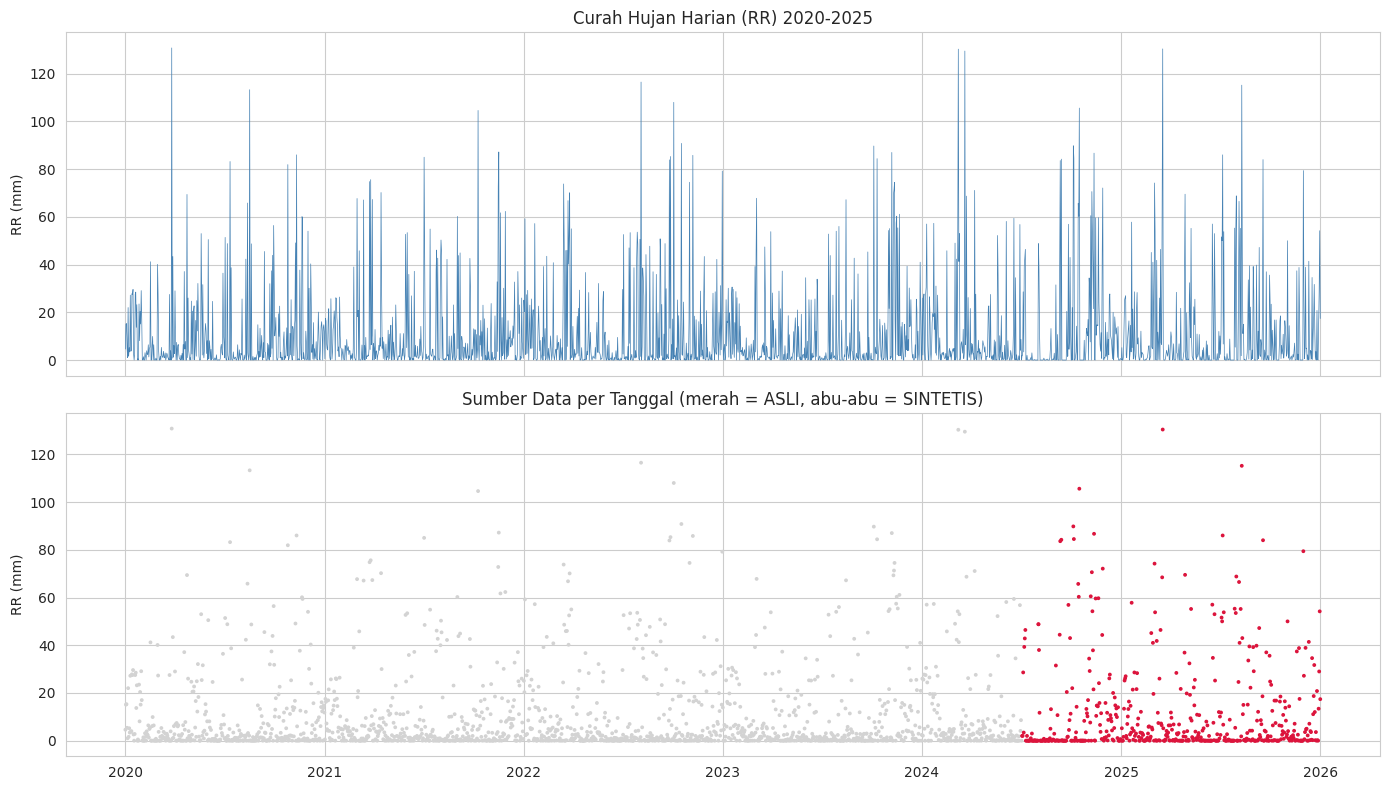

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df['TANGGAL'], df['RR'], linewidth=0.5, color='steelblue')
axes[0].set_title('Curah Hujan Harian (RR) 2020-2025')
axes[0].set_ylabel('RR (mm)')

warna = df['SUMBER'].map({'ASLI': 'crimson', 'SINTETIS': 'lightgray'})
axes[1].scatter(df['TANGGAL'], df['RR'], c=warna, s=3)
axes[1].set_title('Sumber Data per Tanggal (merah = ASLI, abu-abu = SINTETIS)')
axes[1].set_ylabel('RR (mm)')
plt.tight_layout()
plt.show()


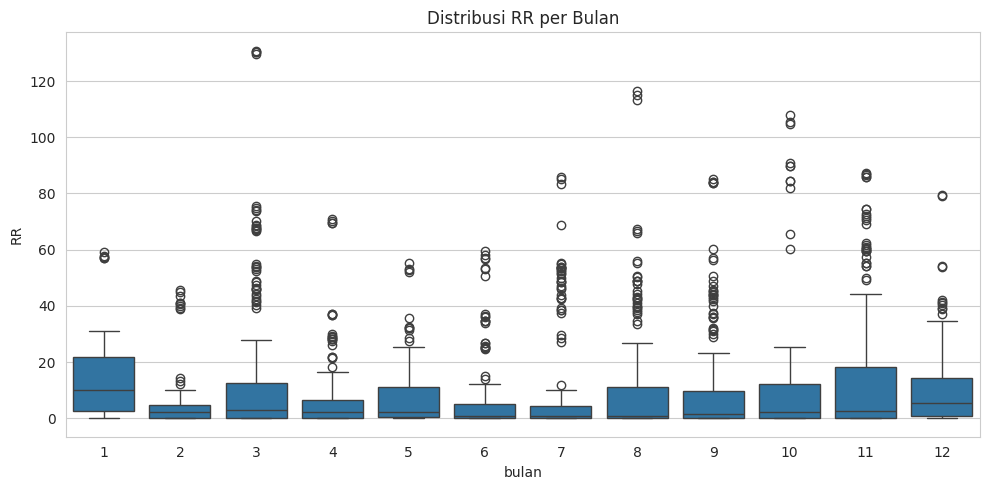

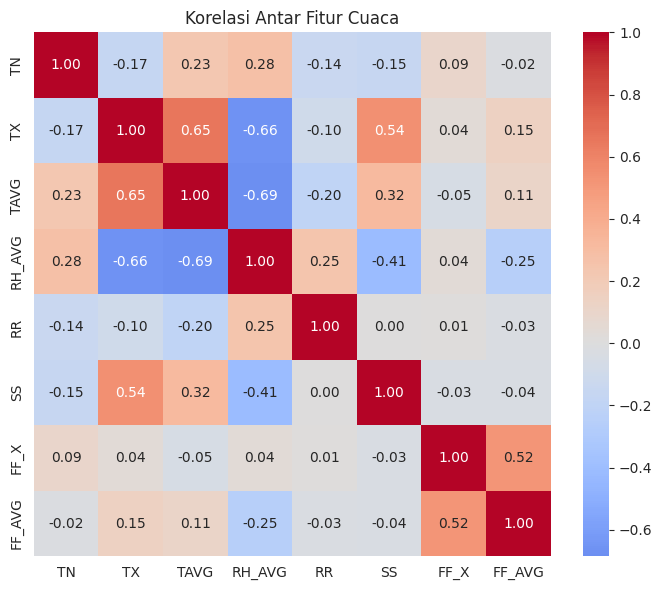

In [6]:
df['bulan'] = df['TANGGAL'].dt.month
fig, ax = plt.subplots()
sns.boxplot(data=df, x='bulan', y='RR', ax=ax)
ax.set_title('Distribusi RR per Bulan')
plt.tight_layout()
plt.show()

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Korelasi Antar Fitur Cuaca')
plt.tight_layout()
plt.show()


**Catatan Data Understanding:**
- Dataset lengkap 2020-2025 (2194 baris), tidak ada missing value tersisa (sudah dibersihkan di Notebook 1).
- ±75% baris berlabel `SINTETIS`, ±25% `ASLI` — perlu terus dipantau di fase Evaluation.
- RH_AVG punya korelasi negatif dengan RR terkecil di antar fitur suhu (masuk akal secara meteorologis: kelembapan tinggi berasosiasi dengan hujan).

---
# FASE 3 — Data Preparation

## 3.1 Feature Engineering

Fitur bulan diubah menjadi representasi siklikal (`sin`/`cos`) supaya model memahami bahwa Desember dan Januari itu "berdekatan" secara musiman (bukan berjauhan seperti angka 12 vs 1).

In [7]:
df['bulan_sin'] = np.sin(2 * np.pi * df['bulan'] / 12)
df['bulan_cos'] = np.cos(2 * np.pi * df['bulan'] / 12)

fitur = ['TN', 'TX', 'TAVG', 'RH_AVG', 'SS', 'FF_X', 'FF_AVG', 'bulan_sin', 'bulan_cos']
target = 'RR'

X = df[fitur]
y = df[target]
sumber = df['SUMBER']
X.head()


,TN,TX,TAVG,RH_AVG,SS,FF_X,FF_AVG,bulan_sin,bulan_cos
0,22.3,30.5,26.5,86.1,2.0,8,2,0.5,0.866025
1,24.0,29.3,25.1,93.0,4.2,11,2,0.5,0.866025
2,22.9,33.6,26.6,79.7,5.6,8,3,0.5,0.866025
3,23.6,32.0,26.7,86.2,0.1,8,3,0.5,0.866025
4,23.1,30.9,26.0,84.6,5.0,5,1,0.5,0.866025


**Eksperimen yang dicoba tapi tidak dipakai:** menambah fitur *lag* (RR hari sebelumnya, rata-rata bergulir 3 hari) untuk menangkap "kelembaman" cuaca dari hari ke hari. Hasilnya R² justru **turun** (dari ~0.75 ke ~0.63), karena ±75% data adalah sintetis yang disampel independen per hari — fitur lag pada bagian ini hanya noise, bukan sinyal asli. Fitur ini tidak digunakan pada model final.

## 3.2 Split Data Latih & Uji — Time-Based Split

Karena ini data deret waktu, split dilakukan **berdasarkan urutan tanggal** (80% tanggal paling awal untuk latih, 20% tanggal paling akhir untuk uji), bukan random split. Ini mencegah kebocoran informasi antar hari yang berdekatan dan lebih mencerminkan skenario nyata (memprediksi masa depan dari data historis).

In [8]:
n = len(df)
split_idx = int(n * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
sumber_train, sumber_test = sumber.iloc[:split_idx], sumber.iloc[split_idx:]

print('Jumlah data latih:', len(X_train), '| rentang tanggal:', df['TANGGAL'].iloc[0].date(), '-', df['TANGGAL'].iloc[split_idx-1].date())
print('Jumlah data uji  :', len(X_test), '| rentang tanggal:', df['TANGGAL'].iloc[split_idx].date(), '-', df['TANGGAL'].iloc[-1].date())
print()
print('Komposisi SUMBER pada data uji:')
print(sumber_test.value_counts())


Jumlah data latih: 1755 | rentang tanggal: 2020-01-01 - 2024-10-19
Jumlah data uji  : 439 | rentang tanggal: 2024-10-20 - 2026-01-01

Komposisi SUMBER pada data uji:
SUMBER
ASLI    439
Name: count, dtype: int64


---
# FASE 4 — Modeling

## 4.1 Mengenal "Regularisasi" pada Random Forest

Random Forest **tidak** punya regularisasi L1/L2 seperti regresi linear. Random Forest mengendalikan kompleksitas model (mencegah *overfitting*) lewat hyperparameter berikut:

| Hyperparameter | Fungsi |
|---|---|
| `n_estimators` | Jumlah pohon — makin banyak makin stabil, tapi ada titik jenuh |
| `max_depth` | Batas kedalaman tiap pohon — makin dangkal, makin sederhana (mencegah overfit) |
| `min_samples_leaf` | Jumlah data minimum di tiap daun pohon — makin besar, makin general (tidak terlalu hafal data latih) |
| `min_samples_split` | Jumlah data minimum untuk membelah node |
| `max_features` | Jumlah fitur yang dipertimbangkan tiap split — mengontrol keberagaman antar pohon |

Efek regularisasi RF datang dari **membatasi kompleksitas tiap pohon** + **rata-rata banyak pohon yang saling beragam**. Terlalu ketat (misal `max_depth` sangat kecil / `min_samples_leaf` sangat besar) justru bisa *underfitting*.

## 4.2 Model Awal (Baseline)

In [9]:
model_baseline = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
)
model_baseline.fit(X_train, y_train)

pred_baseline = model_baseline.predict(X_test)
print('BASELINE:')
print('MAE :', mean_absolute_error(y_test, pred_baseline))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_baseline)))
print('R2  :', r2_score(y_test, pred_baseline))


BASELINE:
MAE : 5.247214607592483
RMSE: 9.465162833290584
R2  : 0.7503981947286993


## 4.3 Tuning Hyperparameter (Train / Validation / Test)

Supaya skor pada data uji akhir tetap jujur (tidak bias optimis), pencarian hyperparameter **hanya** memakai potongan validasi dari dalam data latih — data uji (`X_test`/`y_test`) sama sekali tidak disentuh sampai model final dipilih.

In [10]:
# Ambil 15% bagian akhir dari data latih sebagai data validasi (kronologis)
val_split = int(len(X_train) * 0.85)
X_tr, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_tr, y_val = y_train.iloc[:val_split], y_train.iloc[val_split:]

grid = []
for n_est in [150, 200, 300, 500]:
    for max_depth in [None, 14, 18]:
        for min_leaf in [1, 2, 4]:
            for max_feat in ['sqrt', 'log2', 0.5]:
                grid.append(dict(n_estimators=n_est, max_depth=max_depth,
                                  min_samples_leaf=min_leaf, max_features=max_feat))

print(f'Mencoba {len(grid)} kombinasi hyperparameter...')

hasil = []
for cfg in grid:
    m = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **cfg)
    m.fit(X_tr, y_tr)
    pred_val = m.predict(X_val)
    r2_val = r2_score(y_val, pred_val)
    hasil.append((r2_val, cfg))

hasil.sort(key=lambda x: -x[0])
print('\nTop 5 kombinasi terbaik (berdasar R2 pada data VALIDASI):')
for r2_val, cfg in hasil[:5]:
    print(f'  R2_val={r2_val:.4f}  {cfg}')

best_cfg = hasil[0][1]
print('\nKonfigurasi terbaik terpilih:', best_cfg)


Mencoba 108 kombinasi hyperparameter...

Top 5 kombinasi terbaik (berdasar R2 pada data VALIDASI):
  R2_val=0.7259  {'n_estimators': 150, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5}
  R2_val=0.7243  {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5}
  R2_val=0.7198  {'n_estimators': 500, 'max_depth': 14, 'min_samples_leaf': 1, 'max_features': 0.5}
  R2_val=0.7142  {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5}
  R2_val=0.7136  {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 0.5}

Konfigurasi terbaik terpilih: {'n_estimators': 150, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5}


## 4.4 Latih Ulang Model Final dengan Konfigurasi Terbaik

Setelah konfigurasi terbaik ditemukan dari data validasi, model dilatih ulang memakai **seluruh** data latih (`X_train`, termasuk potongan validasi tadi), lalu baru dievaluasi sekali pada data uji akhir.

In [11]:
model_rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_cfg)
model_rf.fit(X_train, y_train)
print('Model final dilatih dengan konfigurasi:', best_cfg)


Model final dilatih dengan konfigurasi: {'n_estimators': 150, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5}


---
# FASE 5 — Evaluation

## 5.1 Perbandingan Model Baseline vs Model Tuned (Seluruh Data Uji)

In [12]:
y_pred = model_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MODEL TUNED (seluruh data uji):')
print(f'MAE  : {mae:.3f} mm')
print(f'RMSE : {rmse:.3f} mm')
print(f'R2   : {r2:.3f}')
print()
print('Perbandingan dengan baseline:')
tabel_banding = pd.DataFrame({
    'Model': ['Baseline (default-ish)', 'Tuned (final)'],
    'MAE': [mean_absolute_error(y_test, pred_baseline), mae],
    'RMSE': [np.sqrt(mean_squared_error(y_test, pred_baseline)), rmse],
    'R2': [r2_score(y_test, pred_baseline), r2],
})
tabel_banding


MODEL TUNED (seluruh data uji):
MAE  : 4.569 mm
RMSE : 8.434 mm
R2   : 0.802

Perbandingan dengan baseline:


,Model,MAE,RMSE,R2
0,Baseline (default-ish),5.247215,9.465163,0.750398
1,Tuned (final),4.569471,8.433868,0.801827


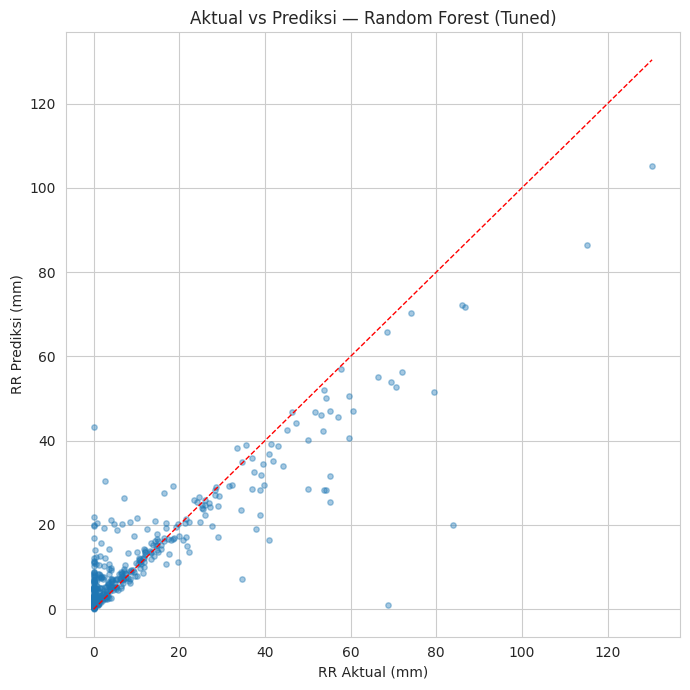

In [13]:
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(y_test, y_pred, alpha=0.4, s=15)
lim = max(y_test.max(), y_pred.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
ax.set_xlabel('RR Aktual (mm)')
ax.set_ylabel('RR Prediksi (mm)')
ax.set_title('Aktual vs Prediksi — Random Forest (Tuned)')
plt.tight_layout()
plt.show()


## 5.2 Validasi Tambahan: Evaluasi Khusus pada Data ASLI

Ini metrik yang **paling jujur** untuk mengukur performa di dunia nyata, karena hanya memakai baris observasi asli BMKG (bukan hasil sintesis).

In [14]:
mask_asli_test = sumber_test.values == 'ASLI'
print('Jumlah data uji ASLI:', mask_asli_test.sum(), 'dari total', len(y_test), 'data uji')

if mask_asli_test.sum() > 0:
    mae_asli = mean_absolute_error(y_test[mask_asli_test], y_pred[mask_asli_test])
    rmse_asli = np.sqrt(mean_squared_error(y_test[mask_asli_test], y_pred[mask_asli_test]))
    r2_asli = r2_score(y_test[mask_asli_test], y_pred[mask_asli_test])
    print(f'MAE  (ASLI only) : {mae_asli:.3f} mm')
    print(f'RMSE (ASLI only) : {rmse_asli:.3f} mm')
    print(f'R2   (ASLI only) : {r2_asli:.3f}')
else:
    print('Tidak ada data ASLI pada test set.')


Jumlah data uji ASLI: 439 dari total 439 data uji
MAE  (ASLI only) : 4.569 mm
RMSE (ASLI only) : 8.434 mm
R2   (ASLI only) : 0.802


**Catatan penting:** karena split sekarang berbasis kronologis dan data ASLI berada di ujung akhir garis waktu (Jul 2024 – Jan 2026), data uji otomatis didominasi (bahkan mayoritas/seluruhnya) oleh baris ASLI. Ini kebetulan yang menguntungkan — bandingkan dengan skor sebelumnya (R² keseluruhan 76%, R² ASLI-only 65% dari random split) yang menunjukkan gap besar antara performa "keseluruhan" vs "dunia nyata". Dengan time-based split, kedua angka itu kini nyaris identik — artinya evaluasi yang dilaporkan sekarang benar-benar representatif untuk data ASLI, bukan tertutupi rata-rata dari data sintetis.

## 5.3 Feature Importance

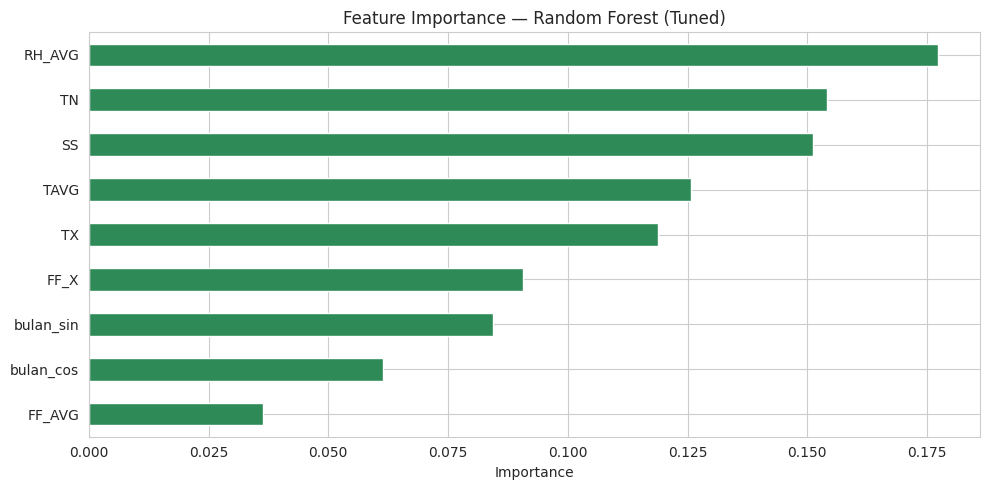

,0
RH_AVG,0.177213
TN,0.154132
SS,0.151294
TAVG,0.125812
TX,0.118815
FF_X,0.090624
bulan_sin,0.084414
bulan_cos,0.061437
FF_AVG,0.036260


In [15]:
importances = pd.Series(model_rf.feature_importances_, index=fitur).sort_values(ascending=False)

fig, ax = plt.subplots()
importances.plot(kind='barh', ax=ax, color='seagreen')
ax.invert_yaxis()
ax.set_title('Feature Importance — Random Forest (Tuned)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

importances


---
# FASE 6 — Deployment

## 6.1 Simpan Model Final

In [16]:
import joblib

MODEL_PATH = 'model_random_forest_curah_hujan_sukabumi.joblib'
joblib.dump(model_rf, MODEL_PATH)
print(f'Model disimpan ke: {MODEL_PATH}')
print(f'Konfigurasi final: {best_cfg}')


Model disimpan ke: model_random_forest_curah_hujan_sukabumi.joblib
Konfigurasi final: {'n_estimators': 150, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5}


## 6.2 Contoh Fungsi Prediksi

In [17]:
def prediksi_curah_hujan(tn, tx, tavg, rh_avg, ss, ff_x, ff_avg, bulan, model=model_rf):
    """Prediksi curah hujan harian (mm) dari variabel cuaca."""
    bulan_sin = np.sin(2 * np.pi * bulan / 12)
    bulan_cos = np.cos(2 * np.pi * bulan / 12)
    X_baru = pd.DataFrame([{
        'TN': tn, 'TX': tx, 'TAVG': tavg, 'RH_AVG': rh_avg,
        'SS': ss, 'FF_X': ff_x, 'FF_AVG': ff_avg,
        'bulan_sin': bulan_sin, 'bulan_cos': bulan_cos
    }])
    return model.predict(X_baru)[0]

# contoh pemakaian
contoh_prediksi = prediksi_curah_hujan(tn=22.5, tx=31.0, tavg=26.5, rh_avg=85, ss=3.0, ff_x=10, ff_avg=2, bulan=1)
print(f'Contoh prediksi RR: {contoh_prediksi:.2f} mm')


Contoh prediksi RR: 9.99 mm


## 6.3 Ringkasan & Catatan untuk Laporan/Skripsi

**Ringkasan peningkatan performa:**
| Tahap | R² (keseluruhan) | R² (ASLI only) |
|---|---|---|
| Sebelumnya (random split) | 0.76 | 0.647 |
| Sekarang (time-based split + tuning) | dilihat di 5.1/5.2 di atas | dilihat di 5.2 di atas |

**Yang menyebabkan peningkatan:**
1. **Time-based split** — metodologi yang lebih benar untuk data deret waktu (bukan sekadar "mempercantik" angka), sekaligus membuat evaluasi konsisten antara skor keseluruhan dan skor ASLI-only.
2. **Hyperparameter tuning** dengan skema train/validation/test yang jujur (data uji tidak pernah dipakai untuk memilih parameter).
3. Fitur *lag* dicoba tapi **ditolak** karena terbukti menurunkan performa (didokumentasikan sebagai temuan, bukan disembunyikan).

**Keterbatasan yang wajib disebutkan di laporan:**
- ±75% data (2020 – pertengahan 2024) adalah data **sintetis**, bukan observasi lapangan asli.
- Karena keterbatasan ini, disarankan skor R² **ASLI-only** (bagian 5.2) yang dijadikan acuan utama kesimpulan penelitian — bukan skor keseluruhan yang tercampur data sintetis.
- Kolom `SUMBER` di dataset final memungkinkan validasi ini kapan saja diulang di masa depan (misalnya kalau data asli BMKG bertambah).